In [1]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import pprint
import warnings
warnings.filterwarnings('ignore')

font_path = '/content/drive/MyDrive/kwukdt/data-analysis/seoul-bicycle-analysis/data/fonts/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Mounted at /content/drive


In [2]:
titanic = pd.read_csv('/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/train.csv')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic_clean = titanic.copy()
titanic_clean = titanic_clean.drop(columns=['Cabin'])
titanic_clean['Age'] = titanic_clean.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

print(f'결측치 전처리 후 최종 결과')
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum() > 0])

print(f'원본 shape: {titanic.shape}')
print(f'전처리 후 shape: {titanic_clean.shape}')

결측치 전처리 후 최종 결과
Series([], dtype: int64)
원본 shape: (891, 12)
전처리 후 shape: (891, 11)


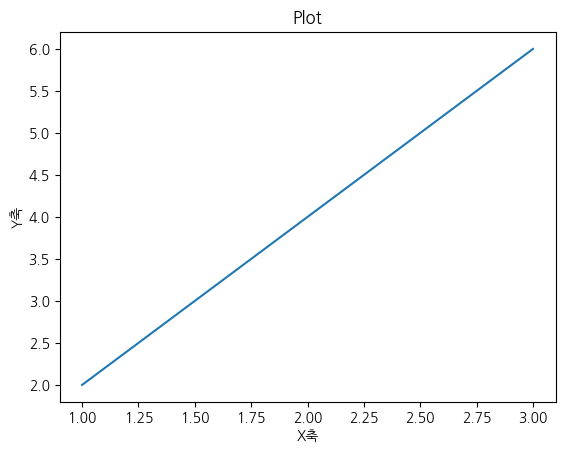

In [17]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [2, 4, 6])   # (x, y)
plt.title('Plot')
plt.xlabel('X축')
plt.ylabel('Y축')
plt.show()

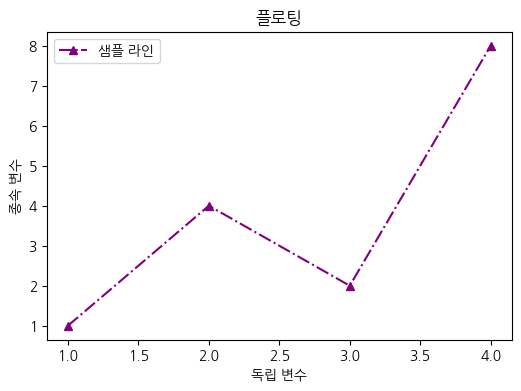

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3, 4], [1, 4, 2, 8], color='purple', marker='^', linestyle='-.', label='샘플 라인')
ax.set_title('플로팅')
ax.set_xlabel('독립 변수')
ax.set_ylabel('종속 변수')
ax.legend()
plt.show()

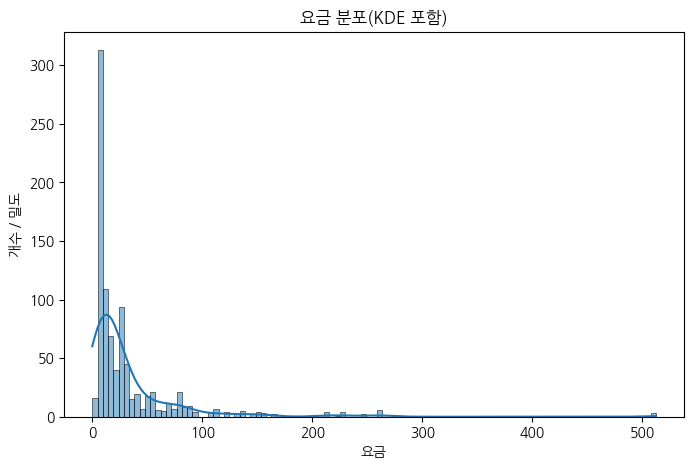

In [19]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=titanic_clean, x='Fare', kde=True)
plt.title('요금 분포(KDE 포함)')
plt.xlabel('요금')
plt.ylabel('개수 / 밀도')
plt.show()

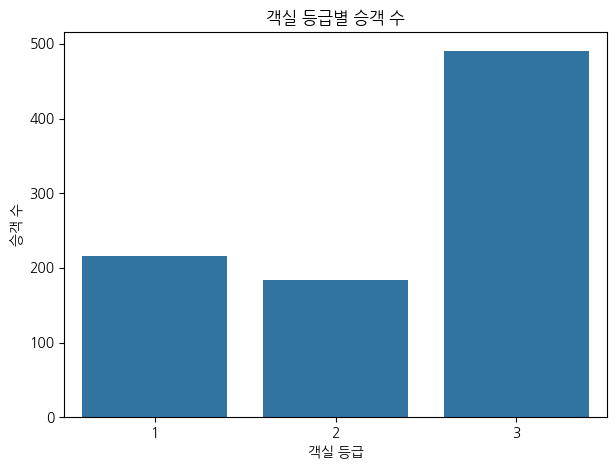

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=titanic_clean, x='Pclass')
plt.title('객실 등급별 승객 수')
plt.xlabel('객실 등급')
plt.ylabel('승객 수')
plt.show()

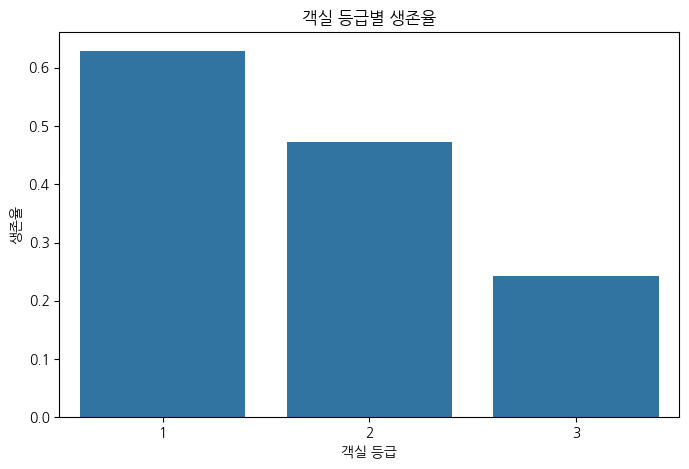

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic_clean, x='Pclass', y='Survived', errorbar=None)
plt.title('객실 등급별 생존율')
plt.xlabel('객실 등급')
plt.ylabel('생존율')
plt.show()

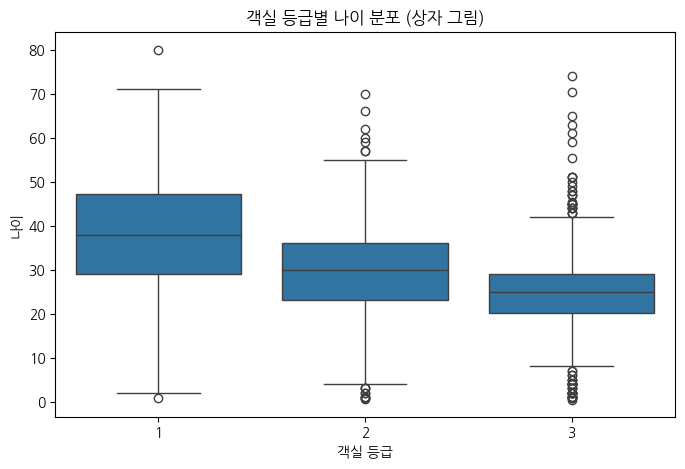

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=titanic_clean, x='Pclass', y='Age')
plt.title('객실 등급별 나이 분포 (상자 그림)')
plt.xlabel('객실 등급')
plt.ylabel('나이')
plt.show()

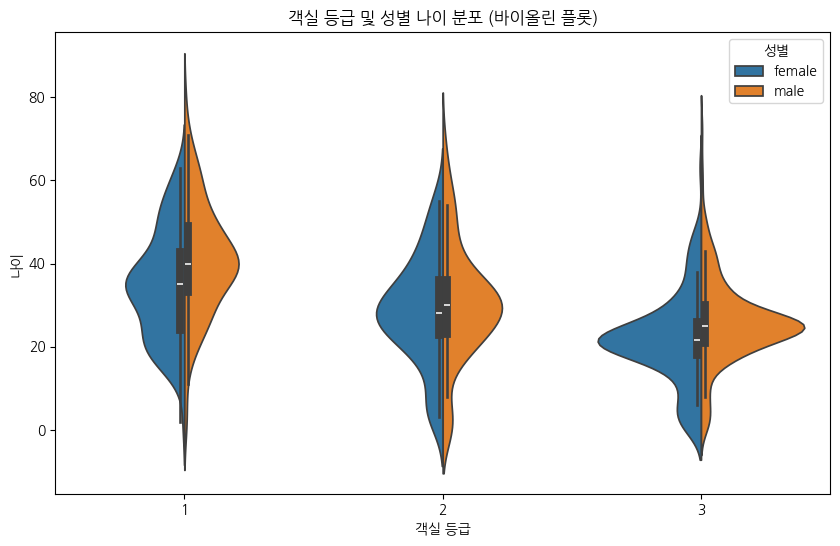

In [23]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=titanic_clean, x='Pclass', y='Age', hue='Sex', split=True)
plt.title('객실 등급 및 성별 나이 분포 (바이올린 플롯)')
plt.xlabel('객실 등급')
plt.ylabel('나이')
plt.legend(title='성별')
plt.show()

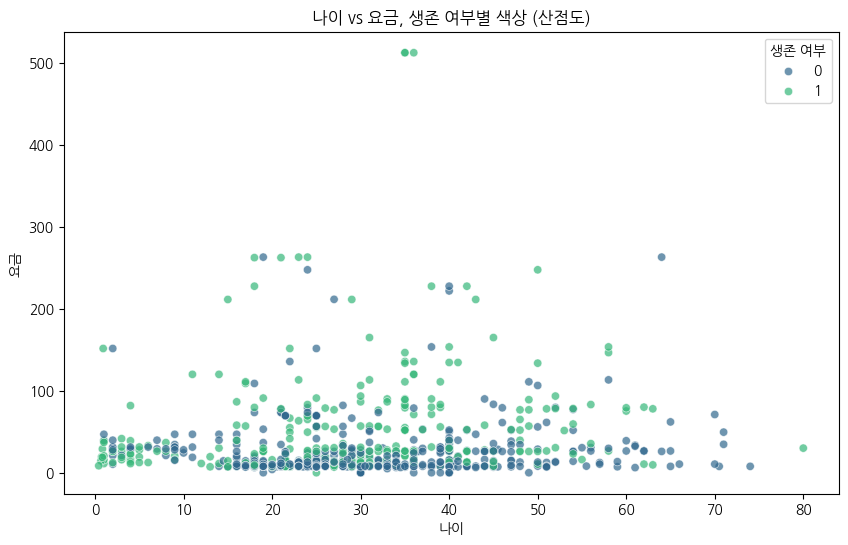

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic_clean, x='Age', y='Fare', hue='Survived', palette='viridis', alpha=0.7)
plt.title('나이 vs 요금, 생존 여부별 색상 (산점도)')
plt.xlabel('나이')
plt.ylabel('요금')
plt.legend(title='생존 여부', loc='upper right')
plt.show()

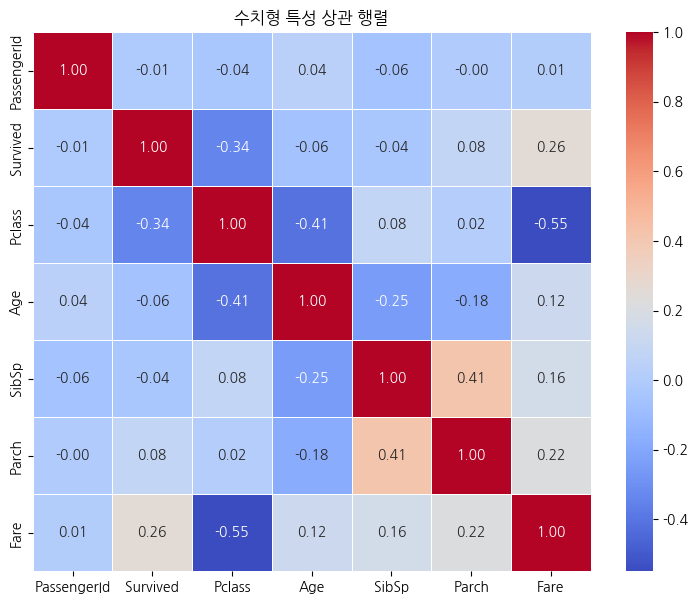

In [25]:
numeric_cols = titanic_clean.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = titanic_clean[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('수치형 특성 상관 행렬')
plt.show()

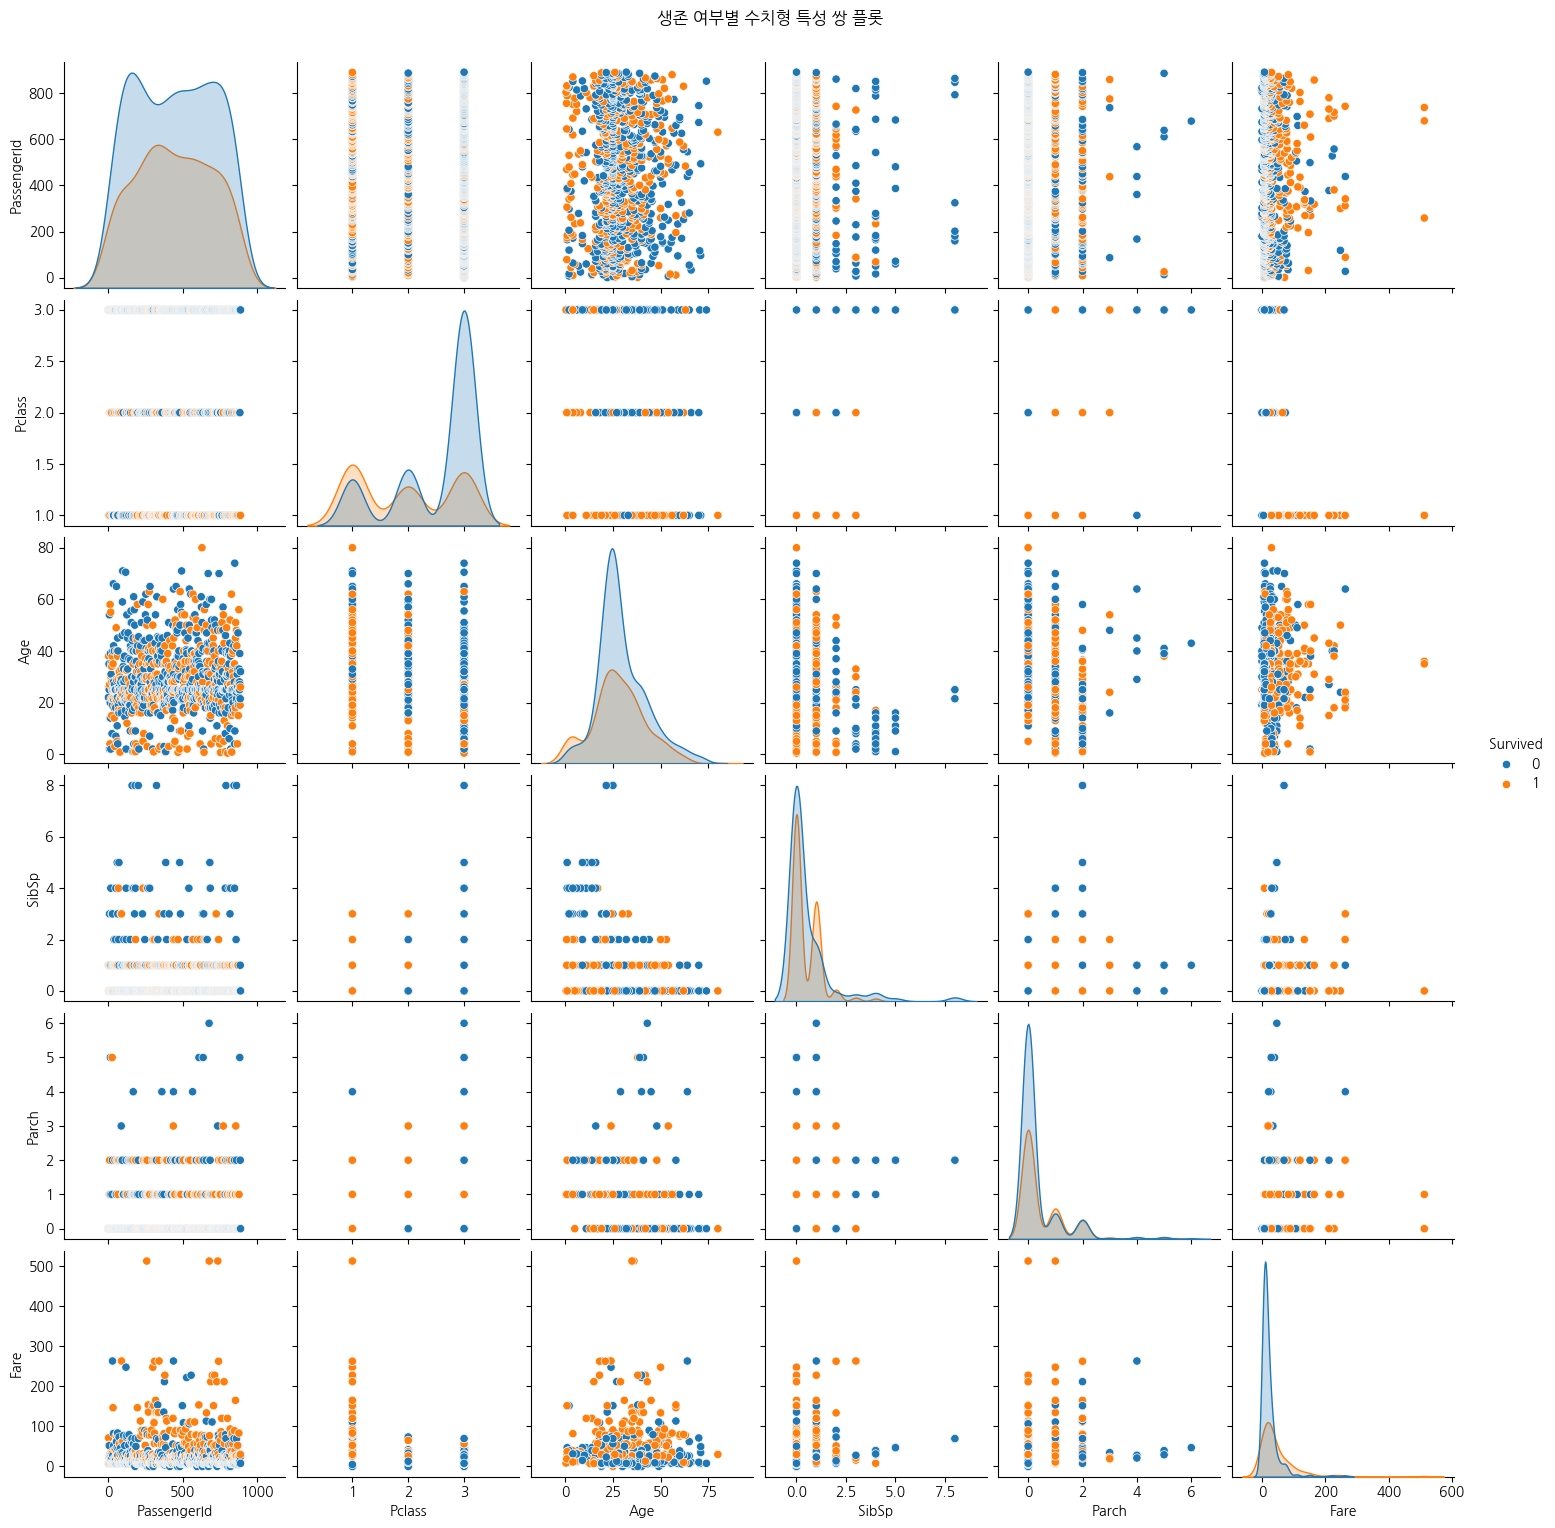

In [26]:
sns.pairplot(titanic_clean[numeric_cols], hue='Survived', diag_kind='kde')
plt.suptitle('생존 여부별 수치형 특성 쌍 플롯', y=1.02)
plt.show()

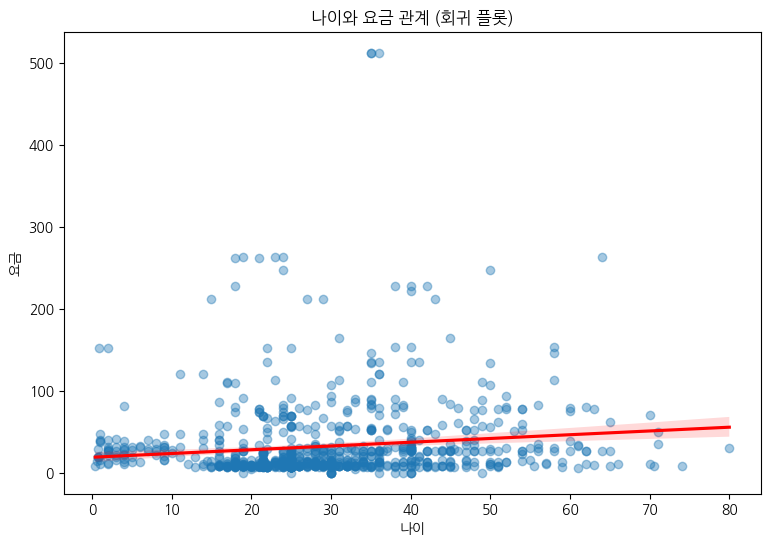

In [27]:
plt.figure(figsize=(9, 6))
sns.regplot(data=titanic_clean, x='Age', y='Fare', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('나이와 요금 관계 (회귀 플롯)')
plt.xlabel('나이')
plt.ylabel('요금')
plt.show()

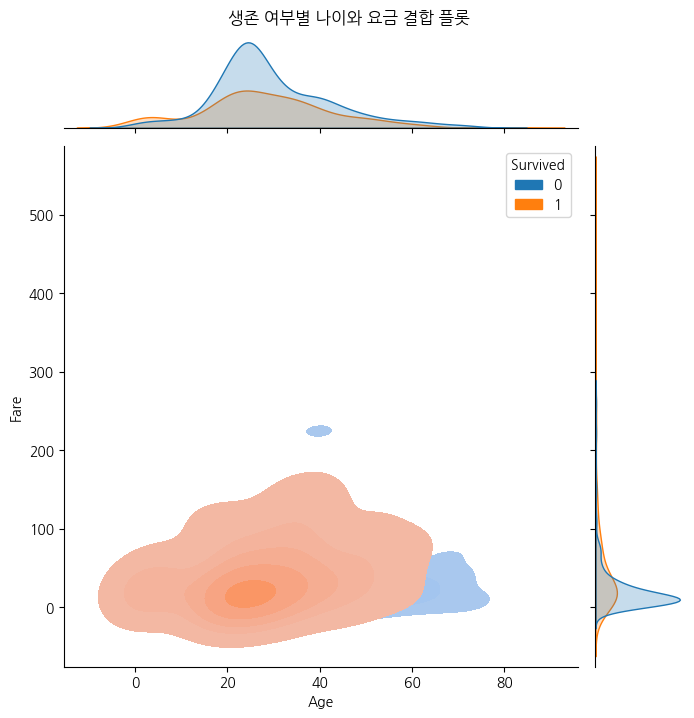

In [15]:
sns.jointplot(data=titanic_clean, x='Age', y='Fare', hue='Survived', kind='kde', fill=True, height=7)
plt.suptitle('생존 여부별 나이와 요금 결합 플롯', y=1.02)
plt.show()

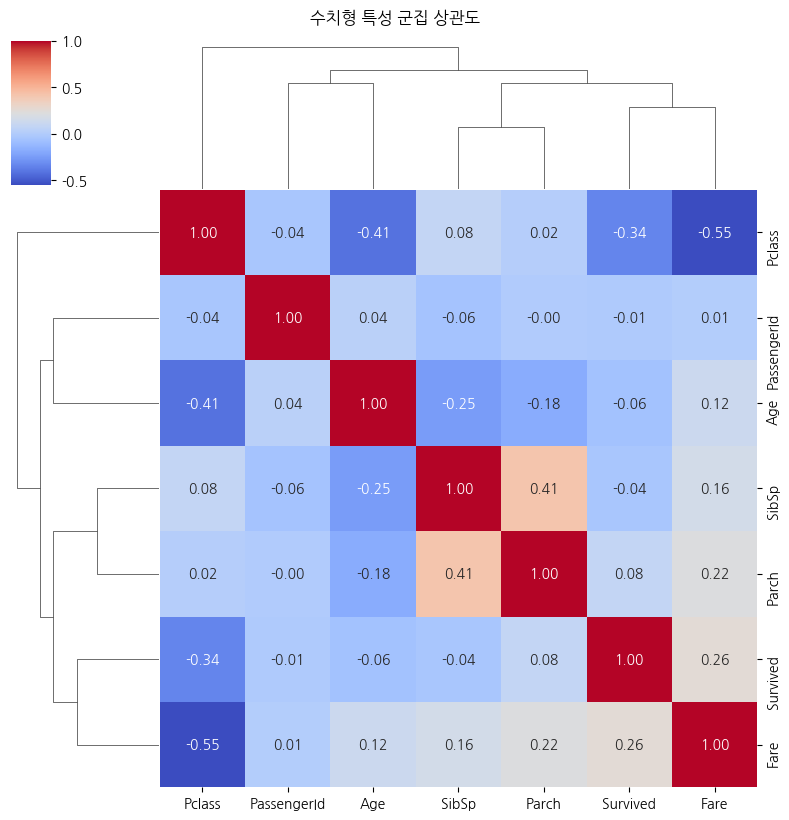

In [16]:
numeric_cols = titanic_clean.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = titanic_clean[numeric_cols].corr()

sns.clustermap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', figsize=(8, 8))
plt.suptitle('수치형 특성 군집 상관도', y=1.02)
plt.show()